In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('CRH','GS'), 
         ('CRH','CAT'), 
         ('CRH','AXP'), 
         ('TDG','GS'), 
         ('TDG', 'CAT'),
         ('TDG', 'AXP'), 
         ('NEM','GS'), 
         ('NEM', 'CAT'), 
         ('NEM','AXP')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

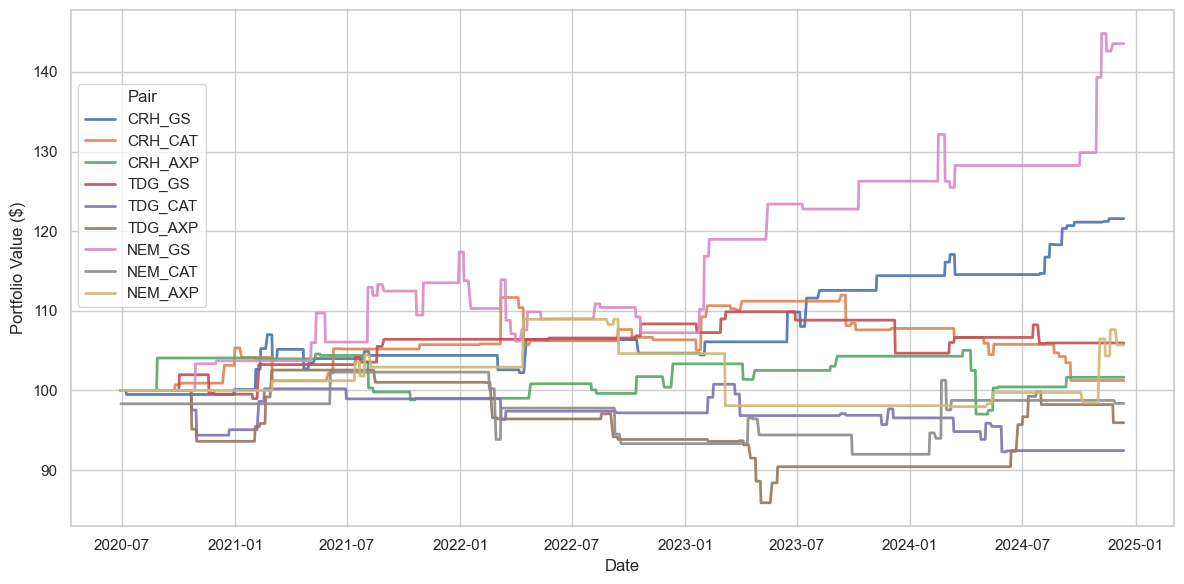

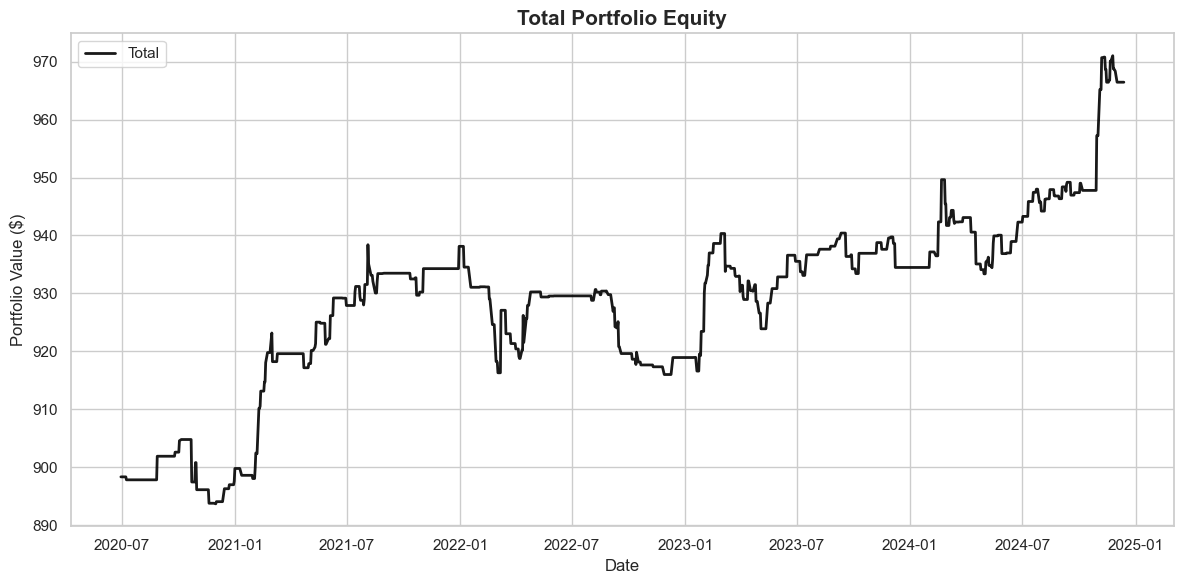

Summary
CRH_GS: Final Value = $121.58, Total Return = 21.58%, Trades = 36
CRH_CAT: Final Value = $101.25, Total Return = 1.25%, Trades = 38
CRH_AXP: Final Value = $101.65, Total Return = 1.65%, Trades = 28
TDG_GS: Final Value = $105.96, Total Return = 5.96%, Trades = 22
TDG_CAT: Final Value = $92.45, Total Return = -7.55%, Trades = 25
TDG_AXP: Final Value = $95.94, Total Return = -4.06%, Trades = 30
NEM_GS: Final Value = $143.54, Total Return = 43.54%, Trades = 41
NEM_CAT: Final Value = $98.37, Total Return = 0.06%, Trades = 17
NEM_AXP: Final Value = $105.72, Total Return = 5.72%, Trades = 18

Total Portfolio Performance
Initial Portfolio Value: $898.32
Final Portfolio Value:   $966.47
Total Return:            7.59%

Sharpe Ratios
CRH_GS: Sharpe Ratio = 0.93
CRH_CAT: Sharpe Ratio = 0.08
CRH_AXP: Sharpe Ratio = 0.10
TDG_GS: Sharpe Ratio = 0.36
TDG_CAT: Sharpe Ratio = -0.38
TDG_AXP: Sharpe Ratio = -0.13
NEM_GS: Sharpe Ratio = 0.93
NEM_CAT: Sharpe Ratio = 0.03
NEM_AXP: Sharpe Ratio = 0.22

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)